Abaixo nós criamos as pastas onde colocaremos as imagens que pegamos na API.

In [ ]:
import math, os, io, time
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

import requests
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

OUT_DIRS = []

for x in ['mosaico_Itaim_Bibi', 'mosaico_Av_Paulista', 'mosaico_Av_Paulista', 'mosaico_Vila_Olimpia', 'mosaico_Pinheiros', 'mosaico_Brooklin', 'mosaico_Alphaville_Industrial', 'mosaicoVila_nova_Conceicao', 'mosaico_Inter_Zonas']:
    OUT_DIR = Path(x)
    OUT_DIR.mkdir(exist_ok=True)
    OUT_DIRS.append(OUT_DIR)
    print("Pasta de saída:", OUT_DIR.resolve())

Pasta de saída: C:\Users\PP\OneDrive - Fundação São Paulo\PUC-SP\5 Semestre\Aprendizagem de Máquina\Projeto 02\Trabalho\mosaico_Centro


Abaixo temos os bairros onde pegamos as imagens:
- `Itaim_Bibi`: (-46.685, -23.590, -46.665, -23.575)
- `Av_Paulista`: (-46.669884, -23.580502, -46.633996, -23.552062)
- `Vila_Olimpia` (parte dele): (-46.690, -23.598, -46.670, -23.585)
- `Pinheiros`: (-46.704205, -23.574847, -46.674487, -23.558183)
- `Brooklin`: (-46.699949, -23.620544, -46.682294, -23.596478)
- `Alphaville_Industrial`: (-46.860248, -23.505565, -46.840035, -23.490924)
- `Vila_nova_Conceicao`: (-46.681131339, -23.5980107441, -46.6639652013, -23.585366627)
- `Inter_Zonas`: (-46.692633, -23.596674, -46.680058, -23.581694)

Abaixo visualizamos quantos km² estamos pegando de cada bairro

In [ ]:
BBOX = [(-46.685, -23.590, -46.665, -23.575), (-46.660, -23.572, -46.640, -23.555), (-46.655264, -23.576348, -46.638076, -23.558125), (-46.690, -23.598, -46.670, -23.585), (-46.704205, -23.574847, -46.674487, -23.558183), (-46.699949, -23.620544, -46.682294, -23.596478), (-46.860248, -23.505565, -46.840035, -23.490924), (-46.681131339, -23.5980107441, -46.6639652013, -23.585366627), (-46.692633, -23.596674, -46.680058, -23.581694)]
ZOOM = 19   # MÁXIMO PRÁTICO PARA SP NO ESRI WORLD IMAGERY
neighborhoods = ['Itaim_Bibi', 'Av_Paulista', 'Av_Paulista', 'Vila_Olimpia', 'Pinheiros', 'Brooklin', 'Alphaville_Industrial', 'Vila_nova_Conceicao', 'Inter_Zonas']


def deg_to_meters(lat_ref, dlat, dlon):
    return dlat * 111_132.0, dlon * 111_320.0 * math.cos(math.radians(lat_ref))


for pos, bbox in enumerate(BBOX):
    lon_min, lat_min, lon_max, lat_max = bbox

    h_m, w_m = deg_to_meters((lat_min+lat_max)/2, lat_max-lat_min, lon_max-lon_min)
    print(f"{neighborhoods[pos]}:")
    print(f"\tBbox:  {bbox}")
    print(f"\tZoom:  {ZOOM}  (≈ {156543.03 * math.cos(math.radians((lat_min+lat_max)/2)) / 2**ZOOM:.3f} m/px em SP)")
    print(f"\tÁrea:  {w_m:.0f} m (L-O) x {h_m:.0f} m (N-S)  =  {w_m*h_m/1e6:.2f} km²")

Centro:
	Bbox:  (-46.658302, -23.582674, -46.631094, -23.553645)
	Zoom:  19  (≈ 0.274 m/px em SP)
	Área:  2776 m (L-O) x 3226 m (N-S)  =  8.96 km²


pegando vendo quantos recortes do bairro precisamos fazer para uma visualização boa de cada trecho do bairro selecionado.

In [124]:
def deg2tile(lat, lon, z):
    n = 2.0 ** z
    x = int((lon + 180.0) / 360.0 * n)
    lat_rad = math.radians(lat)
    y = int((1.0 - math.asinh(math.tan(lat_rad)) / math.pi) / 2.0 * n)
    return x, y

def tile2deg(x, y, z):
    n = 2.0 ** z
    lon = x / n * 360.0 - 180.0
    lat_rad = math.atan(math.sinh(math.pi * (1 - 2 * y / n)))
    return math.degrees(lat_rad), lon

for pos, bbox in enumerate(BBOX):
    lon_min, lat_min, lon_max, lat_max = bbox

    x_min, y_max = deg2tile(lat_min, lon_min, ZOOM)
    x_max, y_min = deg2tile(lat_max, lon_max, ZOOM)
    n_cols = x_max - x_min + 1
    n_rows = y_max - y_min + 1
    n_total = n_cols * n_rows

    print(f"{neighborhoods[pos]}:")
    print(f"\tGrade: {n_cols} colunas x {n_rows} linhas  =  {n_total} tiles")
    print(f"\tMosaico final: {n_cols*256} x {n_rows*256} px  (~{n_cols*256*n_rows*256/1e6:.1f} Mpx)")
    print(f"\tTamanho estimado em disco: ~{n_total * 0.085:.0f} MB")

Centro:
	Grade: 41 colunas x 47 linhas  =  1927 tiles
	Mosaico final: 10496 x 12032 px  (~126.3 Mpx)
	Tamanho estimado em disco: ~164 MB


Abaixo estamos declarando a API e sua headers que às fazem funcionar

In [125]:
TILE_URL = "https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}"
HEADERS = {"User-Agent": "PUC-SP-AM-Aula-Educacional/1.0"}

Abaixo baixamos as imagens e posteriormente colocamo-as nas pastas criadas no início do código

In [126]:
def baixar_tile(args):
    z, x, y, pos = args
    path = OUT_DIRS[pos] / f"tile_z{z}_x{x}_y{y}.jpg"
    if path.exists():
        return path, True, 0
    for tentativa in range(3):
        try:
            r = requests.get(TILE_URL.format(z=z, x=x, y=y),
                             headers=HEADERS, timeout=25)
            if r.status_code == 200 and len(r.content) > 2521:  # filtra placeholder
                path.write_bytes(r.content)
                return path, True, tentativa
        except Exception:
            time.sleep(0.5)
    return path, False, 3

for pos, bbox in enumerate(BBOX):
    lon_min, lat_min, lon_max, lat_max = bbox

    x_min, y_max = deg2tile(lat_min, lon_min, ZOOM)
    x_max, y_min = deg2tile(lat_max, lon_max, ZOOM)
    n_cols = x_max - x_min + 1
    n_rows = y_max - y_min + 1
    n_total = n_cols * n_rows

    jobs = [(ZOOM, x, y, pos)
            for x in range(x_min, x_max + 1)
            for y in range(y_min, y_max + 1)]

    print(f"Baixando {len(jobs)} tiles em z={ZOOM}...")
    t0 = time.time()
    ok = falhas = 0
    with ThreadPoolExecutor(max_workers=4) as ex:
        for path, sucesso, _ in ex.map(baixar_tile, jobs):
            if sucesso: ok += 1
            else:       falhas += 1

    dt = time.time() - t0
    mb = sum(p.stat().st_size for p in OUT_DIRS[pos].glob('*.jpg'))/1024/1024
    print(f"OK:    {ok}/{len(jobs)} tiles")
    print(f"Falhas:{falhas}")
    print(f"Tempo: {dt:.1f}s ({len(jobs)/dt:.1f} tiles/s)")
    print(f"Disco: {mb:.1f} MB")

Baixando 1927 tiles em z=19...
OK:    1898/1927 tiles
Falhas:29
Tempo: 700.0s (2.8 tiles/s)
Disco: 26.9 MB


Abaixo fazemos uma visualização amostral das imagens baixadas

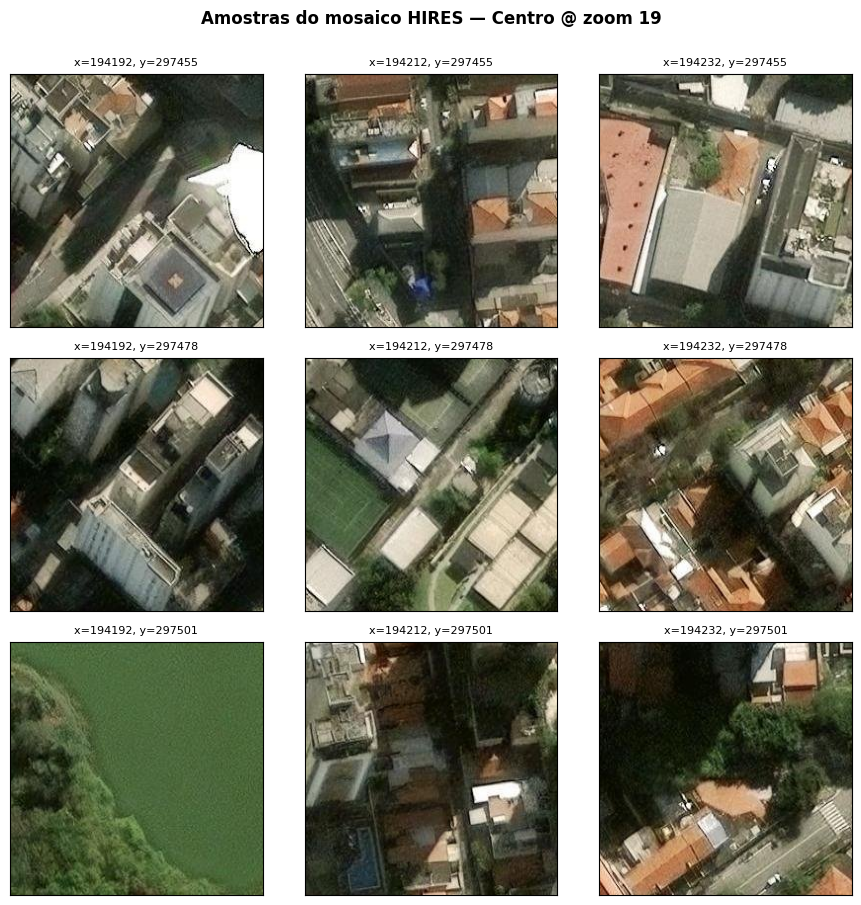

In [127]:
import numpy as np

for pos, bbox in enumerate(BBOX):
    lon_min, lat_min, lon_max, lat_max = bbox
    x_min, y_max = deg2tile(lat_min, lon_min, ZOOM)
    x_max, y_min = deg2tile(lat_max, lon_max, ZOOM)
    n_cols = x_max - x_min + 1
    n_rows = y_max - y_min + 1
    n_total = n_cols * n_rows
    
    jobs = [(ZOOM, x, y)
            for x in range(x_min, x_max + 1)
            for y in range(y_min, y_max + 1)]
    
    xs = np.linspace(x_min, x_max, 3, dtype=int)
    ys = np.linspace(y_min, y_max, 3, dtype=int)

    fig, axes = plt.subplots(3, 3, figsize=(9, 9))
    for i, y in enumerate(ys):
        for j, x in enumerate(xs):
            p = OUT_DIRS[pos] / f"tile_z{ZOOM}_x{x}_y{y}.jpg"
            ax = axes[i, j]
            if p.exists():
                ax.imshow(Image.open(p))
                ax.set_title(f"x={x}, y={y}", fontsize=8)
            ax.set_xticks([]); ax.set_yticks([])

    plt.suptitle(f"Amostras do mosaico HIRES — {neighborhoods[pos]} @ zoom {ZOOM}",
                fontweight="bold", y=1.0)
    plt.tight_layout()
    plt.savefig(f"amostra_tiles_hires_{neighborhoods[pos]}.png", dpi=110, bbox_inches="tight")
    plt.show()

Abaixo visualizamos o bairo por completo

In [128]:
for pos, bbox in enumerate(BBOX):
    lon_min, lat_min, lon_max, lat_max = bbox
    x_min, y_max = deg2tile(lat_min, lon_min, ZOOM)
    x_max, y_min = deg2tile(lat_max, lon_max, ZOOM)
    n_cols = x_max - x_min + 1
    n_rows = y_max - y_min + 1
    n_total = n_cols * n_rows
    TILE_PX = 256
    W, H = n_cols * TILE_PX, n_rows * TILE_PX

    mosaico = Image.new("RGB", (W, H), (0, 0, 0))
    faltando = 0
    for x in range(x_min, x_max + 1):
        for y in range(y_min, y_max + 1):
            p = OUT_DIRS[pos] / f"tile_z{ZOOM}_x{x}_y{y}.jpg"
            if p.exists():
                mosaico.paste(Image.open(p), ((x - x_min) * TILE_PX,
                                            (y - y_min) * TILE_PX))
            else:
                faltando += 1

    print(f"Mosaico HIRES: {W} x {H} px  ({W*H/1e6:.1f} Mpx) — {faltando} tile(s) faltando")

    mosaico.save(f"mosaico_{neighborhoods[pos]}_hires_full.jpg", quality=88)
    preview = mosaico.copy(); preview.thumbnail((3000, 3000))
    preview.save(f"mosaico_{neighborhoods[pos]}_hires_preview.jpg", quality=85)

    plt.figure(figsize=(12, 12 * H / W))
    plt.imshow(preview)
    plt.title(f"Mosaico de {neighborhoods[pos]} HIRES @ z={ZOOM} — {n_cols}x{n_rows} tiles ({W}x{H} px)\n"
            "Source: Esri, Maxar, Earthstar Geographics, and the GIS User Community",
            fontsize=10)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(f"mosaico_{neighborhoods[pos]}_hires_anotado.png", dpi=110, bbox_inches="tight")
    plt.show()

UnidentifiedImageError: cannot identify image file 'mosaico_Centro\\tile_z19_x194225_y297483.jpg'